# Intro

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, pairwise_distances_chunked, average_precision_score
from sklearn.model_selection import GridSearchCV
import numpy as np

In [55]:
df1 = pd.read_csv("data/test.csv")
df2 = pd.read_csv("data/training.csv")

df = pd.concat([df1, df2])

df.head(10)

,RefId,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
0,73015,12/2/2009,ADESA,2005,4,PONTIAC,GRAND PRIX,Bas,4D SEDAN,SILVER,...,9752.0,NaN,NaN,18881,30212,GA,6500.0,0,2152,NaN
1,73016,12/2/2009,ADESA,2005,4,CHEVROLET,MALIBU V6,LS,4D SEDAN LS,SILVER,...,9296.0,NaN,NaN,18111,30212,GA,6300.0,0,1118,NaN
2,73017,12/2/2009,ADESA,2006,3,DODGE,DURANGO 2WD V8,Adv,4D SUV 4.7L ADVENTURER,SILVER,...,16512.0,NaN,NaN,18111,30212,GA,9700.0,0,1215,NaN
3,73018,12/2/2009,ADESA,2002,7,SATURN,L SERIES,L20,4D SEDAN L200,GOLD,...,6398.0,NaN,NaN,18881,30212,GA,4150.0,0,1933,NaN
4,73019,12/2/2009,ADESA,2007,2,HYUNDAI,ACCENT,GS,2D COUPE GS,BLUE,...,7350.0,NaN,NaN,18111,30212,GA,4100.0,0,920,NaN
5,73020,12/2/2009,ADESA,2006,3,DODGE,STRATUS 4C,SXT,4D SEDAN,GREEN,...,8102.0,NaN,NaN,18881,30212,GA,4200.0,0,1341,NaN
6,73021,12/2/2009,ADESA,2006,3,FORD,EXPLORER 2WD V6,XLS,4D SUV 4.0L XLS,BROWN,...,14650.0,NaN,NaN,18881,30212,GA,8500.0,0,1155,NaN
7,73022,12/2/2009,ADESA,2003,6,CHRYSLER,PT CRUISER,Tou,4D SEDAN LIMITED,BLUE,...,7734.0,NaN,NaN,18881,30212,GA,4100.0,0,1689,NaN
8,73023,12/2/2009,ADESA,2005,4,CHEVROLET,MALIBU 4C,Bas,4D SEDAN,SILVER,...,8507.0,NaN,NaN,18111,30212,GA,5900.0,0,764,NaN
9,73024,12/2/2009,ADESA,2006,3,CHRYSLER,TOWN & COUNTRY FWD V,Tou,MINIVAN 3.8L,WHITE,...,15506.0,NaN,NaN,18111,30212,GA,6700.0,0,1623,NaN


In [56]:
df['PurchDate'] = pd.to_datetime(df['PurchDate'])

In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 121690 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   RefId                              121690 non-null  int64         
 1   PurchDate                          121690 non-null  datetime64[us]
 2   Auction                            121690 non-null  str           
 3   VehYear                            121690 non-null  int64         
 4   VehicleAge                         121690 non-null  int64         
 5   Make                               121690 non-null  str           
 6   Model                              121690 non-null  str           
 7   Trim                               117780 non-null  str           
 8   SubModel                           121677 non-null  str           
 9   Color                              121678 non-null  str           
 10  Transmission                       12

In [58]:
df = df.dropna(subset=["IsBadBuy"])

In [59]:
for columns in df.columns:
    if (df[columns].dtype != "str" and df[columns].dtype != "datetime64[us]") and df[columns].isna().sum() >= 1:
        print(columns, end=" ")
        print(df[columns].isna().sum(), end=" / ")
        df[columns] = df[columns].fillna(df[columns].mean())
        print(df[columns].isna().sum())

WheelTypeID 3169 / 0
MMRAcquisitionAuctionAveragePrice 18 / 0
MMRAcquisitionAuctionCleanPrice 18 / 0
MMRAcquisitionRetailAveragePrice 18 / 0
MMRAcquisitonRetailCleanPrice 18 / 0
MMRCurrentAuctionAveragePrice 315 / 0
MMRCurrentAuctionCleanPrice 315 / 0
MMRCurrentRetailAveragePrice 315 / 0
MMRCurrentRetailCleanPrice 315 / 0


In [60]:
for columns in df.columns:
    if (df[columns].dtype == "str" or df[columns].dtype == "datetime64[us]") and df[columns].isna().sum() >= 1:
        print(columns, end=" ")
        print(df[columns].isna().sum(), end=" / ")
        df[columns] = df[columns].fillna("missing")
        print(df[columns].isna().sum())

Trim 2360 / 0
SubModel 8 / 0
Color 8 / 0
Transmission 9 / 0
WheelType 3174 / 0
Nationality 5 / 0
Size 5 / 0
TopThreeAmericanName 5 / 0
PRIMEUNIT 69564 / 0
AUCGUART 69564 / 0


Удалим по соответствующим причинам: дублирование колонки, дублирование индексов, дублирование колонки, слишком большая колонка для onehotencoding'а, слишком большая колонка для onehotencoding'а. Последние 2 колонки будут замещены логически колонкой VNST.

In [61]:
df = df.drop(columns=["VehYear", "RefId", "WheelTypeID", "VNZIP1", "BYRNO"])
df = df.sort_values(by='PurchDate').reset_index(drop=True)

df.head(10)

,PurchDate,Auction,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelType,...,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
0,2009-01-05,MANHEIM,2,CHRYSLER,PACIFICA FWD 3.8L V6,Bas,4D SPORT,BLUE,AUTO,Covers,...,10331.0,9906.0,11657.0,missing,missing,CO,6770.0,0,1389,0.0
1,2009-01-05,MANHEIM,4,FORD,FREESTAR FWD V6 3.9L,SES,4D PASSENGER 3.9L SES,SILVER,AUTO,Alloy,...,5971.0,5801.0,6949.0,missing,missing,CO,6160.0,0,941,0.0
2,2009-01-05,MANHEIM,5,DODGE,STRATUS 4C 2.4L I4 M,SE,4D SEDAN SE,SILVER,AUTO,Covers,...,4272.0,4169.0,5114.0,missing,missing,CO,4250.0,0,1155,0.0
3,2009-01-05,MANHEIM,3,CHEVROLET,TRAILBLAZER EXT 4WD,LS,4D SUV 4.2L,WHITE,AUTO,Alloy,...,10794.0,10438.0,12158.0,missing,missing,CO,8180.0,0,1703,0.0
4,2009-01-05,MANHEIM,5,FORD,TAURUS 3.0L V6 EFI,SES,4D SEDAN SES DURATEC,GOLD,AUTO,Alloy,...,4492.0,4139.0,5351.0,missing,missing,CO,4900.0,0,825,0.0
5,2009-01-05,MANHEIM,4,CHEVROLET,IMPALA 3.4L V6 SFI,Bas,4D SEDAN,GOLD,AUTO,Covers,...,5857.0,5597.0,6826.0,missing,missing,NC,5600.0,0,2152,0.0
6,2009-01-05,MANHEIM,6,FORD,MUSTANG V6 3.8L V6 E,Bas,2D COUPE,SILVER,AUTO,Alloy,...,6075.0,5973.0,7061.0,missing,missing,NC,6400.0,0,1028,0.0
7,2009-01-05,MANHEIM,5,DODGE,STRATUS 4C 2.4L I4 M,SXT,4D SEDAN SE,GOLD,AUTO,Alloy,...,4361.0,4126.0,5210.0,missing,missing,NC,4700.0,0,1020,0.0
8,2009-01-05,MANHEIM,5,DODGE,DURANGO 4WD V8 4.7L,SLT,4D SUV 4.7L,SILVER,AUTO,Alloy,...,9461.0,9458.0,10718.0,missing,missing,NC,7600.0,0,1411,0.0
9,2009-01-05,MANHEIM,3,FORD,FREESTYLE AWD V6 3.0,SE,4D CUV 3.0L SE,GREEN,AUTO,Alloy,...,8354.0,7589.0,9522.0,missing,missing,NC,6700.0,0,1623,1.0


In [62]:
def train_valid_test_split(df):    
    dates = df['PurchDate'].unique()
    train_end = dates[len(dates) // 3 - 1]
    valid_end = dates[2 * (len(dates) // 3) - 1]

    train_df = df[df['PurchDate'] <= train_end].drop('PurchDate', axis=1)
    valid_df = df[(df['PurchDate'] > train_end) & (df['PurchDate'] <= valid_end)].drop('PurchDate', axis=1)
    test_df = df[(df['PurchDate'] > valid_end)].drop('PurchDate', axis=1)
    
    return train_df, valid_df, test_df

train_df, valid_df, test_df = train_valid_test_split(df)

In [63]:
def gini_score_skl(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1


In [64]:
categorial_columns = []
numeric_columns = []

for columns in df.columns:
    if (df[columns].dtype == "str" or df[columns].dtype == "datetime64[us]"):
        categorial_columns.append(columns)
    else:
        numeric_columns.append(columns)
        
numeric_columns.remove("IsBadBuy")
categorial_columns.remove('PurchDate')

In [65]:
X_train = train_df.drop(columns="IsBadBuy")
y_train = train_df["IsBadBuy"]

X_valid = valid_df.drop(columns="IsBadBuy")
y_valid = valid_df["IsBadBuy"]

X_test = test_df.drop(columns="IsBadBuy")
y_test = test_df["IsBadBuy"]

In [66]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()

X_train_df = X_train.copy()

X_cat = encoder.fit_transform(X_train_df[categorial_columns])
X_num = scaler.fit_transform(X_train_df[numeric_columns])

all_columns = numeric_columns + list(encoder.get_feature_names_out(categorial_columns))

X_combined = np.hstack([X_num, X_cat])
X_train_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_train_df.index)


X_valid_df = X_valid.copy()
X_cat = encoder.transform(X_valid_df[categorial_columns])
X_num = scaler.transform(X_valid_df[numeric_columns])

X_combined = np.hstack([X_num, X_cat])
X_valid_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_valid_df.index)


X_test_df = X_test.copy()
X_cat = encoder.transform(X_test_df[categorial_columns])
X_num = scaler.transform(X_test_df[numeric_columns])

X_combined = np.hstack([X_num, X_cat])
X_test_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_test_df.index)


X_train_scaled = X_train_scaled.dropna()
y_train = y_train.loc[X_train_scaled.index]

X_valid_scaled = X_valid_scaled.dropna()
y_valid = y_valid.loc[X_valid_scaled.index]

X_test_scaled = X_valid_scaled.dropna()
y_test = y_valid.loc[X_valid_scaled.index]

In [67]:
logreg = LogisticRegression(random_state=21, max_iter=1000)

logreg.fit(X_train_scaled, y_train)

valid_proba_logreg = logreg.predict_proba(X_valid_scaled)[:, 1]

In [68]:
knn = KNeighborsClassifier(n_neighbors=25)

knn.fit(X_train_scaled, y_train)

valid_proba_knn = knn.predict_proba(X_valid_scaled)[:, 1]

In [69]:
gaussian = GaussianNB()

gaussian.fit(X_train_scaled, y_train)

valid_proba_gaussian = gaussian.predict_proba(X_valid_scaled)[:, 1]

In [70]:
print(f"LogisticRegression - gini: {gini_score_skl(y_valid, valid_proba_logreg):.5f}; roc auc: {roc_auc_score(y_valid, valid_proba_logreg):.5f}")
print(f"KNN - gini: {gini_score_skl(y_valid, valid_proba_knn):.5f}; roc auc: {roc_auc_score(y_valid, valid_proba_knn):.5f}")
print(f"GaussianNB - gini: {gini_score_skl(y_valid, valid_proba_gaussian):.5f}; roc auc: {roc_auc_score(y_valid, valid_proba_gaussian):.5f}")

LogisticRegression - gini: 0.39196; roc auc: 0.69598
KNN - gini: 0.34140; roc auc: 0.67070
GaussianNB - gini: 0.05270; roc auc: 0.52635


Получим Gini 0,392 для LogisticRegression

In [ ]:
def roc_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    
    tpr = [0.0]
    fpr = [0.0]
    tp = fp = i = 0
    
    while i < len(y_true):
        curr = y_score[i]
        while i < len(y_true) and y_score[i] == curr:
            if y_true[i] == 1:
                tp += 1
            else:
                fp += 1
            i += 1
        tpr.append(tp / np.sum(y_true == 1))
        fpr.append(fp / np.sum(y_true == 0))
    
    roc = 0.0
    for i in range (1, len(tpr)):
        roc += (fpr[i] - fpr[i - 1]) * ((tpr[i] + tpr[i - 1]) / 2)
    
    return roc

def gini_score(y_true, y_score):
    return 2 * roc_auc(y_true, y_score) - 1


In [72]:
print(f"LogisticRegression - gini: {gini_score(y_valid, valid_proba_logreg):.5f}; roc auc: {roc_auc(y_valid, valid_proba_logreg):.5f}")
print(f"GaussianNB - gini: {gini_score(y_valid, valid_proba_gaussian):.5f}; roc auc: {roc_auc(y_valid, valid_proba_gaussian):.5f}")
print(f"KNN - gini: {gini_score(y_valid, valid_proba_knn):.5f}; roc auc: {roc_auc(y_valid, valid_proba_knn):.5f}")

LogisticRegression - gini: 0.39196; roc auc: 0.69598
GaussianNB - gini: 0.05270; roc auc: 0.52635
KNN - gini: 0.34140; roc auc: 0.67070


Данные сошлись

# LogReg, KNN, NaiveBayes

In [73]:
class MyLogReg:
    def __init__(self, learning_rate=0.1, n_iters=1000, reg_st=0.01):
        self.weights = None
        self.bias = None
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.reg_st = reg_st
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_iters):
            linear = X.dot(self.weights) + self.bias
            p = self.sigmoid(linear)
            
            dw = X.T.dot(p - y) / n_samples
            db = np.sum(p - y) / n_samples
            dw += (self.reg_st / n_samples) * self.weights
        
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        return self.sigmoid(X.dot(self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [74]:
myLogreg = MyLogReg()
myLogreg.fit(X_train_scaled, y_train)

valid_proba_my_logreg = myLogreg.predict_proba(X_valid_scaled)

print(f"My LogisticRegression - gini: {gini_score(y_valid, valid_proba_my_logreg):.5f}; roc auc: {roc_auc(y_valid, valid_proba_my_logreg):.5f}")

My LogisticRegression - gini: 0.48406; roc auc: 0.74203


Получили gini выше чем в sklearn-реализации

In [75]:
class MyKNeighborsClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_mem = None
        self.y_mem = None
        
    def fit(self, X, y):
        self.X_mem = X.copy()
        self.y_mem = y.copy()
        
    def predict_proba(self, X):
        probas = []
        gen = pairwise_distances_chunked(X, self.X_mem,
                                     reduce_func=lambda chunk, start: chunk,
                                     working_memory=512)
        for distances_block in gen:
            for row_dist in distances_block:
                k_indices = np.argsort(row_dist)[:self.k]
                k_labels = self.y_mem.iloc[k_indices]
                probas.append([1 - np.mean(k_labels), np.mean(k_labels)])
        return np.array(probas)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)



In [76]:
myKNN = MyKNeighborsClassifier(k=25)
myKNN.fit(X_train_scaled, y_train)

valid_proba_my_knn = myKNN.predict_proba(X_valid_scaled)[:, 1]

print(f"My KNN - gini: {gini_score(y_valid, valid_proba_my_knn):.5f}; roc auc: {roc_auc(y_valid, valid_proba_my_knn):.5f}")

My KNN - gini: 0.34140; roc auc: 0.67070


Получим такой же gini как в sklearn-реализации

In [77]:
class MyGaussianNB:
    def __init__(self):
        self.var_smoothing = 1e-9
        self.prior_0 = None
        self.prior_1 = None
        self.mean_0 = None
        self.mean_1 = None
        self.var_0 = None
        self.var_1 = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        X_0 = X[y == 0]
        X_1 = X[y == 1]

        n_total = X.shape[0]
        self.prior_0 = X_0.shape[0] / n_total
        self.prior_1 = X_1.shape[0] / n_total

        self.mean_0 = X_0.mean(axis=0)
        self.mean_1 = X_1.mean(axis=0)

        self.var_0 = X_0.var(axis=0)
        self.var_1 = X_1.var(axis=0)

        max_var = max(np.max(self.var_0), np.max(self.var_1))
        self.var_0 += max_var * self.var_smoothing
        self.var_1 += max_var * self.var_smoothing

    def _joint_log_likelihood(self, X):
        X = np.asarray(X)

        log_prior_0 = np.log(self.prior_0)
        log_det_0 = np.sum(np.log(2.0 * np.pi * self.var_0))
        diff_0 = X - self.mean_0
        sum_sq_scaled_0 = np.sum((diff_0 ** 2) / self.var_0, axis=1)
        log_likelihood_0 = -0.5 * (log_det_0 + sum_sq_scaled_0)
        jll_0 = log_prior_0 + log_likelihood_0

        log_prior_1 = np.log(self.prior_1)
        log_det_1 = np.sum(np.log(2.0 * np.pi * self.var_1))
        diff_1 = X - self.mean_1
        sum_sq_scaled_1 = np.sum((diff_1 ** 2) / self.var_1, axis=1)
        log_likelihood_1 = -0.5 * (log_det_1 + sum_sq_scaled_1)
        jll_1 = log_prior_1 + log_likelihood_1

        return np.column_stack((jll_0, jll_1))

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        log_proba = jll - np.max(jll, axis=1, keepdims=True)
        proba = np.exp(log_proba)
        proba /= np.sum(proba, axis=1, keepdims=True)
        return proba

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [78]:
myGaussian = MyGaussianNB()

myGaussian.fit(X_train_scaled, y_train)

valid_proba_my_gaussian = myGaussian.predict_proba(X_valid_scaled)[:, 1]

print(f"GaussianNB - gini: {gini_score_skl(y_valid, valid_proba_my_gaussian):.5f}; roc auc: {roc_auc_score(y_valid, valid_proba_my_gaussian):.5f}")

GaussianNB - gini: 0.05270; roc auc: 0.52635


Получим такой же gini как в sklearn-реализации

# Non-linear features

In [79]:
df_non_linear = df.copy()

In [80]:
df_non_linear["NewIntensityOfWear"] = df_non_linear["VehOdo"] / (df_non_linear["VehicleAge"] + 1)
df_non_linear["NewDeviationOfOverpayment"] = (df_non_linear["VehBCost"] - df_non_linear["MMRAcquisitionAuctionAveragePrice"]) / (df_non_linear["MMRAcquisitionAuctionAveragePrice"] + 1e-9)
df_non_linear["NewWarrantyToCost"] = df_non_linear["WarrantyCost"] / (df_non_linear["VehBCost"] + 1e-9)

df_non_linear["NewMakeVehbcostMean"] = (df_non_linear["Make"]
            .map(df_non_linear.groupby("Make")["VehBCost"].mean())
            .fillna(df_non_linear["VehBCost"].mean()))

df_non_linear["NewModelVehbcostMean"] = (df_non_linear["Model"]
            .map(df_non_linear.groupby("Model")["VehBCost"].mean())
            .fillna(df_non_linear["VehBCost"].mean()))

df_non_linear["NewCostToMakeMean"] = (
            df_non_linear["VehBCost"] / (df_non_linear["NewMakeVehbcostMean"] + 1e-9))

df_non_linear["NewCostToModelMean"] = (
            df_non_linear["VehBCost"] / (df_non_linear["NewModelVehbcostMean"] + 1e-9))


In [81]:
train_df, valid_df, test_df = train_valid_test_split(df_non_linear)

numeric_columns.extend(["NewIntensityOfWear", "NewDeviationOfOverpayment",
                       "NewWarrantyToCost", "NewMakeVehbcostMean",
                       "NewModelVehbcostMean", "NewCostToMakeMean", "NewCostToModelMean"])

X_train = train_df.drop(columns="IsBadBuy")
y_train = train_df["IsBadBuy"]

X_valid = valid_df.drop(columns="IsBadBuy")
y_valid = valid_df["IsBadBuy"]

X_test = test_df.drop(columns="IsBadBuy")
y_test = test_df["IsBadBuy"]

In [83]:
X_train_df = X_train.copy()

X_cat = encoder.fit_transform(X_train_df[categorial_columns])
X_num = scaler.fit_transform(X_train_df[numeric_columns])

all_columns = numeric_columns + list(encoder.get_feature_names_out(categorial_columns))

X_combined = np.hstack([X_num, X_cat])
X_train_non_linear_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_train_df.index)


X_valid_df = X_valid.copy()
X_cat = encoder.transform(X_valid_df[categorial_columns])
X_num = scaler.transform(X_valid_df[numeric_columns])

X_combined = np.hstack([X_num, X_cat])
X_valid_non_linear_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_valid_df.index)


X_test_df = X_test.copy()
X_cat = encoder.transform(X_test_df[categorial_columns])
X_num = scaler.transform(X_test_df[numeric_columns])

X_combined = np.hstack([X_num, X_cat])
X_test_non_linear_scaled = pd.DataFrame(X_combined, columns=all_columns, index=X_test_df.index)


X_train_non_linear_scaled = X_train_non_linear_scaled.dropna()
y_train_non_linear = y_train.loc[X_train_non_linear_scaled.index]

X_valid_non_linear_scaled = X_valid_non_linear_scaled.dropna()
y_valid_non_linear = y_valid.loc[X_valid_non_linear_scaled.index]

X_test_non_linear_scaled = X_test_non_linear_scaled.dropna()
y_test_non_linear = y_test.loc[X_test_non_linear_scaled.index]

In [84]:
logreg.fit(X_train_non_linear_scaled, y_train_non_linear)

valid_proba_logreg_non_linear = logreg.predict_proba(X_valid_non_linear_scaled)[:, 1]

In [85]:
knn.fit(X_train_non_linear_scaled, y_train_non_linear)

valid_proba_knn_non_linear = knn.predict_proba(X_valid_non_linear_scaled)[:, 1]

In [86]:
gaussian.fit(X_train_non_linear_scaled, y_train_non_linear)

valid_proba_gaussian_non_linear = gaussian.predict_proba(X_valid_non_linear_scaled)[:, 1]

In [87]:
print(f"LogisticRegression_non_linear - gini: {gini_score_skl(y_valid_non_linear, valid_proba_logreg_non_linear):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_logreg_non_linear):.5f}")
print(f"KNN_non_linear - gini: {gini_score_skl(y_valid_non_linear, valid_proba_knn_non_linear):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_knn_non_linear):.5f}")
print(f"GaussianNB_non_linear - gini: {gini_score_skl(y_valid_non_linear, valid_proba_gaussian_non_linear):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_gaussian_non_linear):.5f}")

LogisticRegression_non_linear - gini: 0.42199; roc auc: 0.71100
KNN_non_linear - gini: 0.31800; roc auc: 0.65900
GaussianNB_non_linear - gini: 0.05270; roc auc: 0.52635


Получили результат для logreg выше (ниже для своего logreg, ввиду отсутстия настроенных гиперпараметров), для KNN чуть ниже и такой же для GaussianNB. Для KNN доабавление новых коррелирующих признаков создает только шум, а GaussianNB предполагает что признаки независимы, поэтому не улучшает gini.

# Best features

In [88]:
feature_names = X_train_non_linear_scaled.columns.to_list()
coeffs = logreg.coef_[0]
sorted_idx = np.argsort(coeffs)[::-1]

In [89]:
def get_feature_name(feature_name):
    try:
        return feature_name[:feature_name.index("_")]
    except ValueError:
        return feature_name


In [90]:
top_features_manual = pd.DataFrame({
    "feature_name": np.array(feature_names)[sorted_idx],
    "coeffs": coeffs[sorted_idx],
    "abs_coeffs": np.abs(coeffs[sorted_idx])
})

top_features_manual = top_features_manual.sort_values("abs_coeffs", ascending=False)

top_features_manual.head(10)

,feature_name,coeffs,abs_coeffs
0,WheelType_missing,2.431793,2.431793
1699,Model_MONTANA 3.4L V6 SFI,-1.549625,1.549625
1698,SubModel_4D SEDAN SE COMFORT,-1.505476,1.505476
1,Model_AVEO 1.6L I4 DOHC,1.260911,1.260911
2,SubModel_REG CAB 5.4L XLT,1.232638,1.232638
3,Model_IMPALA 3.8L V6 MFI S,1.219093,1.219093
5,Model_XL-7 2WD 2.7L V6 DI,1.212599,1.212599
4,SubModel_4D SPORT UTILITY 5 PASS,1.212599,1.212599
6,Model_MONTERO SPORT 4WD V6,1.169981,1.169981
7,SubModel_4D SEDAN SEL FFV,1.161081,1.161081


In [91]:
top_features_manual["original_feature_name"] = top_features_manual["feature_name"].apply(get_feature_name)

top_features_manual = (
    top_features_manual
    .groupby("original_feature_name")
    .agg(
        max_abs_coeffs=("abs_coeffs", "max"),
        mean_abs_coeffs=("abs_coeffs", "mean"),
        features_count=("feature_name", "count")
    )
    .sort_values("max_abs_coeffs", ascending=False)
)

top_features_manual.head(15)

,max_abs_coeffs,mean_abs_coeffs,features_count
original_feature_name,,,
WheelType,2.431793,1.239500,4
Model,1.549625,0.276108,795
SubModel,1.505476,0.277468,651
Trim,1.059886,0.277377,123
VNST,0.859320,0.331646,29
Make,0.807047,0.173186,31
PRIMEUNIT,0.749375,0.702168,2
AUCGUART,0.749375,0.702168,2
Transmission,0.709815,0.441739,3


In [92]:
top_features_manual_names = top_features_manual.head(15).index.to_list()

top_features_manual_names

['WheelType',
 'Model',
 'SubModel',
 'Trim',
 'VNST',
 'Make',
 'PRIMEUNIT',
 'AUCGUART',
 'Transmission',
 'Color',
 'Nationality',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice',
 'VehBCost',
 'MMRAcquisitionAuctionAveragePrice']

In [94]:
filtered_columns = [col for col in X_train_non_linear_scaled.columns if any(col.startswith(p) for p in top_features_manual_names)]
X_train_non_linear_manual_scaled = X_train_non_linear_scaled[filtered_columns]
X_valid_non_linear_manual_scaled = X_valid_non_linear_scaled[filtered_columns]

logreg.fit(X_train_non_linear_manual_scaled, y_train_non_linear)

valid_proba_logreg_non_linear_manual = logreg.predict_proba(X_valid_non_linear_manual_scaled)[:, 1]

print(f"LogisticRegression_non_linear_manual - gini: {gini_score_skl(y_valid_non_linear, valid_proba_logreg_non_linear_manual):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_logreg_non_linear_manual):.5f}")

LogisticRegression_non_linear_manual - gini: 0.39559; roc auc: 0.69779


Получили gini хуже чем со всеми признаками

Теперь реализуем с l1


In [95]:
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_search_logreg = GridSearchCV(estimator=logreg, param_grid=param_grid_logreg, scoring="roc_auc", cv=3, n_jobs=3)
grid_search_logreg.fit(X_train_non_linear_scaled, y_train_non_linear)

print(grid_search_logreg.best_params_)

{'C': 0.01}


In [96]:
logreg_l1 = LogisticRegression(random_state=21, max_iter=1000, C=0.01)

logreg_l1.fit(X_train_non_linear_scaled, y_train_non_linear)

feature_names = X_train_non_linear_scaled.columns.to_list()
coeffs = logreg_l1.coef_[0]
sorted_idx = np.argsort(coeffs)[::-1]

top_features_l1 = pd.DataFrame({
    "feature_name": np.array(feature_names)[sorted_idx],
    "coeffs": coeffs[sorted_idx],
    "abs_coeffs": np.abs(coeffs[sorted_idx])
})

top_features_l1 = top_features_l1.sort_values("abs_coeffs", ascending=False)

top_features_l1.head(10)

,feature_name,coeffs,abs_coeffs
0,WheelType_missing,1.547031,1.547031
1699,WheelType_Covers,-0.749979,0.749979
1698,WheelType_Alloy,-0.694962,0.694962
1,VehicleAge,0.294244,0.294244
2,VNST_TX,0.218427,0.218427
3,VehOdo,0.187932,0.187932
1697,VNST_FL,-0.185189,0.185189
4,VNST_VA,0.179844,0.179844
1696,Model_STRATUS V6 2.7L V6 M,-0.163771,0.163771
1695,SubModel_4D SEDAN SXT FFV,-0.159170,0.159170


In [97]:
top_features_l1["original_feature_name"] = top_features_l1["feature_name"].apply(get_feature_name)

top_features_l1 = (
    top_features_l1
    .groupby("original_feature_name")
    .agg(
        max_abs_coeffs=("abs_coeffs", "max"),
        mean_abs_coeffs=("abs_coeffs", "mean"),
        features_count=("feature_name", "count")
    )
    .sort_values("max_abs_coeffs", ascending=False)
)

top_features_l1.head(15)

,max_abs_coeffs,mean_abs_coeffs,features_count
original_feature_name,,,
WheelType,1.547031,0.773698,4
VehicleAge,0.294244,0.294244,1
VNST,0.218427,0.054146,29
VehOdo,0.187932,0.187932,1
Model,0.163771,0.009119,795
SubModel,0.159170,0.008954,651
Transmission,0.123132,0.082331,3
Trim,0.116623,0.016894,123
Size,0.114491,0.059781,12


In [98]:
top_features_l1_names = top_features_l1.head(15).index.to_list()

filtered_columns = [col for col in X_train_non_linear_scaled.columns if any(col.startswith(p) for p in top_features_l1_names)]
X_train_non_linear_l1_scaled = X_train_non_linear_scaled[filtered_columns]
X_valid_non_linear_l1_scaled = X_valid_non_linear_scaled[filtered_columns]
X_test_non_linear_l1_scaled = X_test_non_linear_scaled[filtered_columns]

logreg.fit(X_train_non_linear_l1_scaled, y_train_non_linear)

valid_proba_logreg_non_linear_l1 = logreg.predict_proba(X_valid_non_linear_l1_scaled)[:, 1]

print(f"LogisticRegression_non_linear_l1 - gini: {gini_score_skl(y_valid_non_linear, valid_proba_logreg_non_linear_l1):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_logreg_non_linear_l1):.5f}")

LogisticRegression_non_linear_l1 - gini: 0.45677; roc auc: 0.72839


Получим лучший gini для logreg

# Hyperparameters

In [99]:
logreg = LogisticRegression(random_state=21)

param_grid_logreg = {
    'max_iter': [1000, 5000, 10000],
    'class_weight': ['balanced', None],
    'solver': ['lbfgs', 'liblinear'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_search_logreg = GridSearchCV(estimator=logreg, param_grid=param_grid_logreg,
                                  scoring="roc_auc", cv=3, n_jobs=3)

grid_search_logreg.fit(X_train_non_linear_l1_scaled, y_train_non_linear)

grid_search_logreg.best_params_

{'C': 0.01,
 'class_weight': 'balanced',
 'max_iter': 1000,
 'solver': 'liblinear'}

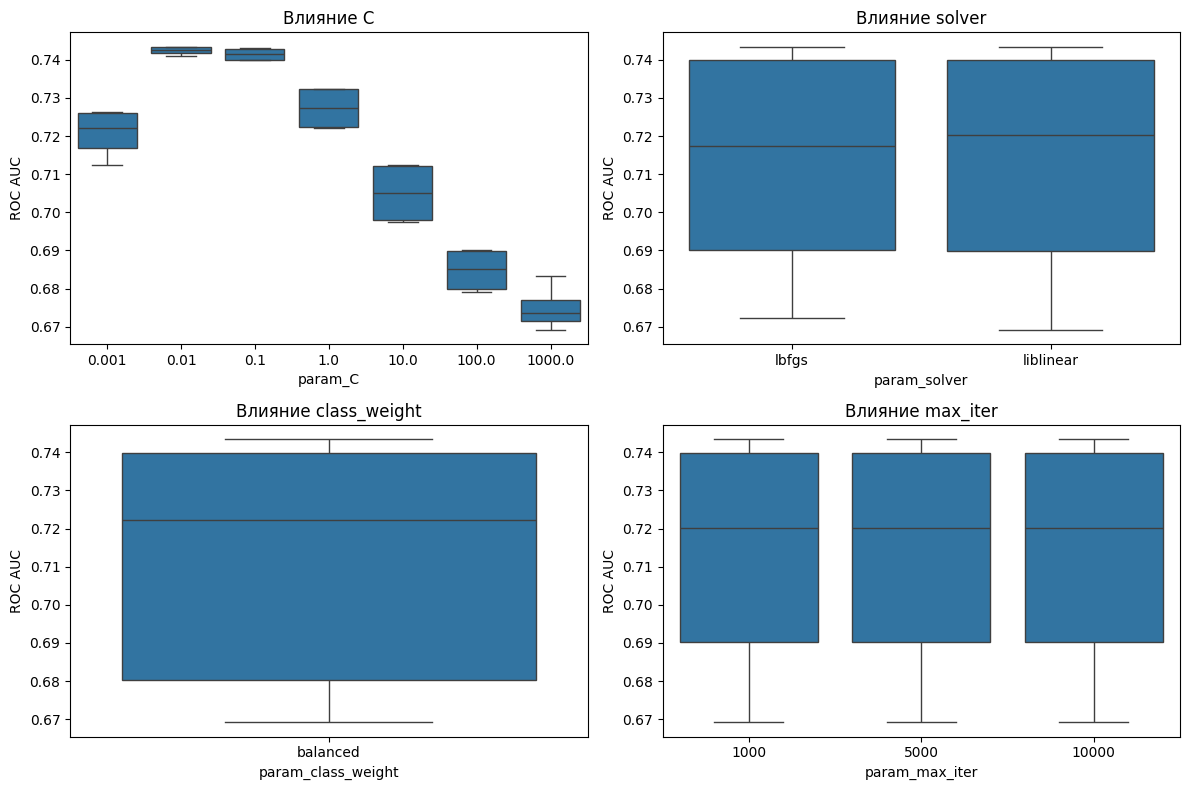

In [100]:
results = pd.DataFrame(grid_search_logreg.cv_results_)

impact = {}
for param in ['C', 'solver', 'class_weight', 'max_iter']:
    grouped = results.groupby(f'param_{param}')['mean_test_score'].mean()
    impact[param] = grouped.max() - grouped.min()
    
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, param in zip(axes.flat, ['C', 'solver', 'class_weight', 'max_iter']):
    sns.boxplot(data=results, x=f'param_{param}', y='mean_test_score', ax=ax)
    ax.set_title(f'Влияние {param}')
    ax.set_ylabel('ROC AUC')
plt.tight_layout()
plt.show()

In [101]:
logreg = grid_search_logreg.best_estimator_
valid_proba_GS_logreg_non_linear_l1 = logreg.predict_proba(X_valid_non_linear_l1_scaled)[:, 1]

print(f"LogisticRegression_GS_non_linear_l1 - gini: {gini_score_skl(y_valid_non_linear, valid_proba_GS_logreg_non_linear_l1):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba_GS_logreg_non_linear_l1):.5f}")

LogisticRegression_GS_non_linear_l1 - gini: 0.49177; roc auc: 0.74588


Видим что наибольшее влияние оказывает параметр С, при значении 0.01

# Gini check

In [102]:
train_proba = logreg.predict_proba(X_train_non_linear_l1_scaled)[:, 1]
valid_proba = logreg.predict_proba(X_valid_non_linear_l1_scaled)[:, 1]
test_proba = logreg.predict_proba(X_test_non_linear_l1_scaled)[:, 1]

print(f"LogisticRegression_GS_non_linear_l1 train - gini: {gini_score_skl(y_train_non_linear, train_proba):.5f}; roc auc: {roc_auc_score(y_train_non_linear, train_proba):.5f}")
print(f"LogisticRegression_GS_non_linear_l1 valid - gini: {gini_score_skl(y_valid_non_linear, valid_proba):.5f}; roc auc: {roc_auc_score(y_valid_non_linear, valid_proba):.5f}")
print(f"LogisticRegression_GS_non_linear_l1 test - gini: {gini_score_skl(y_test_non_linear, test_proba):.5f}; roc auc: {roc_auc_score(y_test_non_linear, test_proba):.5f}")

LogisticRegression_GS_non_linear_l1 train - gini: 0.53927; roc auc: 0.76963
LogisticRegression_GS_non_linear_l1 valid - gini: 0.49177; roc auc: 0.74588
LogisticRegression_GS_non_linear_l1 test - gini: 0.50250; roc auc: 0.75125


Видим что просадок практически нет: gini даже больше на test чем на valid, значит модель не сильно переобучена

# Metrics

In [117]:
threshold = 0.5
y_pred_bin = (test_proba >= threshold).astype(int)

In [118]:
def my_precision(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    
    return tp / (tp + fp + 1e-9)


In [119]:
def my_recall(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp / (tp + fn + 1e-9)


In [120]:
def my_f1(y_true, y_pred):
    precision = my_precision(y_true, y_pred)
    recall = my_recall(y_true, y_pred)
    
    return 2 * precision * recall / (precision + recall + 1e-9)


In [121]:
def my_auc_pr(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    order = np.argsort(y_pred)[::-1]
    y_true = y_true[order]
    y_pred_sorted = y_pred[order]
    
    points = []
    for thresh in y_pred_sorted:
        y_pred_bin = (y_pred_sorted >= thresh).astype(int)
        p = my_precision(y_true, y_pred_bin)
        r = my_recall(y_true, y_pred_bin)
        points.append((r, p))
    
    points = sorted(set(points), key=lambda x: x[0])
    
    if points[0][0] > 0:
        points.insert(0, (0.0, 1.0))
    if points[-1][0] < 1.0:
        points.append((1.0, 0.0))
    
    recalls, precisions = zip(*points)
    
    area = sum((recalls[i] - recalls[i-1]) * (precisions[i] + precisions[i-1]) / 2
               for i in range(1, len(recalls)))
    return area


In [124]:
print(f"LogisticRegression_GS_non_linear_l1 test - precision: {my_precision(y_test_non_linear, y_pred_bin):.5f}; recall: {my_recall(y_test_non_linear, y_pred_bin):.5f}")
print(f"LogisticRegression_GS_non_linear_l1 test - f1: {my_f1(y_test_non_linear, y_pred_bin):.5f}; auc pr: {my_auc_pr(y_test_non_linear, test_proba):.5f}")

LogisticRegression_GS_non_linear_l1 test - precision: 0.24911; recall: 0.62066
LogisticRegression_GS_non_linear_l1 test - f1: 0.35553; auc pr: 0.44828


И сравним с sklearn-реализацией

In [126]:
print(f"LogisticRegression_GS_non_linear_l1 test - precision: {precision_score(y_test_non_linear, y_pred_bin):.5f}; recall: {recall_score(y_test_non_linear, y_pred_bin):.5f}")
print(f"LogisticRegression_GS_non_linear_l1 test - f1: {f1_score(y_test_non_linear, y_pred_bin):.5f}; auc pr: {average_precision_score(y_test_non_linear, test_proba):.5f}")

LogisticRegression_GS_non_linear_l1 test - precision: 0.24911; recall: 0.62066
LogisticRegression_GS_non_linear_l1 test - f1: 0.35553; auc pr: 0.44838


Как видим, данные сошлись

Также видим много ложноположительных срабатываний, но взамен низкой точности получаем большой recall

# Lemon cars

Для бизнеса опаснее ложноотрицательные предсказания(покупка плохого авто), чем ложноположительные(потеря дохода), т.е. нужно смотреть на более высокий recall